# Hướng Dẫn Giải Thích Chi Tiết: `src/data_loader.py`

Notebook này phân tích cấu trúc, công dụng và cách hoạt động của tệp `src/data_loader.py`. File này đóng vai trò cực kỳ quan trọng trong khâu chuẩn bị dữ liệu đầu vào cho toàn bộ hệ thống dự báo.

---

## 🔍 1. Tổng Quan Về Các Thư Viện Sử Dụng

Trong `data_loader.py`, chúng ta nhập các thư viện chính:
- `yfinance as yf`: Tải dữ liệu chứng khoán trực tuyến từ Yahoo Finance.
- `pandas as pd` và `numpy as np`: Xử lý và tính toán bảng dữ liệu.
- `pandas_ta as ta`: Thư viện tính toán các chỉ báo phân tích kỹ thuật.
- `urllib.request`: Gửi yêu cầu HTTP đến DNSE API để tải dữ liệu lịch sử của VNM.

In [1]:
import sys
import os
# Thêm thư mục gốc vào đường dẫn hệ thống để import src
sys.path.append(os.path.abspath('..'))

from src.data_loader import fetch_and_prepare_data, format_vn
print("Import thành công!")

Import thành công!


## ⚙️ 2. Công Dụng Của Các Hàm Trong `data_loader.py`

### Hàm `format_vn(value)`
- **Mục đích:** Định dạng một số thực thành chuỗi hiển thị tiền tệ VNĐ (ngăn cách hàng nghìn bằng dấu chấm và thêm đuôi VNĐ).
- **Ví dụ:** `format_vn(65000.5)` -> `"65.000,50 VNĐ"`.

In [2]:
price = 15427452.12
print(f"Giá gốc: {price}")
print(f"Sau định dạng: {format_vn(price)}")

Giá gốc: 15427452.12
Sau định dạng: 15.427.452,12


#### Bước B: Tải bổ sung dữ liệu lịch sử trước 2019 của Vinamilk
Dữ liệu trường chỉ bắt đầu từ năm 2019. Để huấn luyện Transformer sâu hơn, hàm sử dụng DNSE Chart API để tải thêm dữ liệu từ năm 2012. API sử dụng Epoch Timestamp để yêu cầu dữ liệu:
`https://services.entrade.com.vn/chart-api/v2/ohlcs/stock?from={start_epoch}&to={end_epoch}&symbol=VNM&resolution=1D`

**ĐỒNG BỘ MÚI GIỜ CỤC BỘ (Asia/Ho_Chi_Minh):** DNSE Chart API trả về thời gian dạng Unix millisecond epoch. Hệ thống sử dụng thư viện `pytz` để chuyển đổi Unix Epoch trực tiếp sang múi giờ `Asia/Ho_Chi_Minh` trước khi chuyển thành kiểu Date của Pandas. Việc này giúp loại bỏ hoàn toàn các lỗi lệch ngày (lệch 7 tiếng so với UTC) khi hợp nhất dữ liệu từ nhiều nguồn khác nhau.

#### Bước C: Hợp nhất và loại bỏ trùng lặp
Dữ liệu được sắp xếp theo thời gian tăng dần, loại bỏ các ngày trùng lặp giữa các nguồn bằng hàm `.drop_duplicates(subset=['date'])`.


In [3]:
# Thử tải dữ liệu mẫu cho Vinamilk và hiển thị bảng dữ liệu
df_sample = fetch_and_prepare_data("VNM.VN", start_date="2023-01-01", end_date="2023-06-01")
print(f"Kích thước dữ liệu mẫu: {df_sample.shape}")
print("\nCác cột dữ liệu và chỉ báo kỹ thuật đã tạo:")
print(df_sample.columns.tolist())

# Hiển thị 5 dòng đầu tiên
df_sample[['date', 'open', 'close', 'close_smoothed', 'market_return']].head()

Đang tải tỷ giá USD/VND (USDVND=X) từ 2023-01-01 đến 2023-06-01...


Đang tải Yahoo Finance: VNM.VN...


[*********************100%***********************]  1 of 1 completed

  Yahoo Finance: 108 phiên
Đang nạp dữ liệu trường: C:\Users\ACER\Documents\Stock-Opening-Price-Prediction\data\raw\VNM_prices.csv
  Tổng: 1621 phiên (2019-09-17 → 2026-03-16)
Tính macro features...


  [NEWS] Tải và phân tích cảm xúc tin tức cho VNM.VN...


📥 Đang tải dữ liệu cổ tức cho VNM.VN từ yfinance...


   => Đã tải 0 đợt chia cổ tức cho VNM.VN
Đã lưu cache: C:\Users\ACER\Documents\Stock-Opening-Price-Prediction\data\VNM.VN_processed.csv
Sẵn sàng với 1617 phiên.

Kích thước dữ liệu mẫu: (1617, 38)

Các cột dữ liệu và chỉ báo kỹ thuật đã tạo:
['date', 'open', 'high', 'low', 'close', 'volume', 'market_return', 'vix', 'bond_yield_10y', 'dollar_index_change', 'sp500', 'nasdaq', 'sp500_above_ma200', 'nasdaq_12m_return', 'vnm_etf', 'vnm_etf_above_ma200', 'usdvnd_change', 'vix_lag1', 'bond_yield_lag1', 'vnindex_return_lag1', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'is_quarter_end', 'days_before_tet', 'close_smoothed', 'sentiment_score', 'news_volume', 'dividend_flag', 'days_to_dividend', 'days_after_dividend', 'target_return_1d', 'target_spread_1d', 'target_return_2d', 'target_spread_2d', 'target_return_3d', 'target_spread_3d']


,date,open,close,close_smoothed,market_return
0,2019-09-18,73830.0,74850.0,74488.390677,0.0
1,2019-09-19,74730.0,74790.0,74588.761409,0.0
2,2019-09-20,74850.0,73890.0,74413.894013,0.0
3,2019-09-23,74430.0,75340.0,74599.857347,0.0
4,2019-09-24,75340.0,76790.0,74967.616750,0.0


## 📈 3. Trực Quan Hóa Chỉ Báo Đã Tính Toán

Hãy vẽ biểu đồ giá đóng cửa kèm theo giá đóng cửa Kalman làm mịn và tỷ suất sinh lời thị trường vừa được sinh ra.

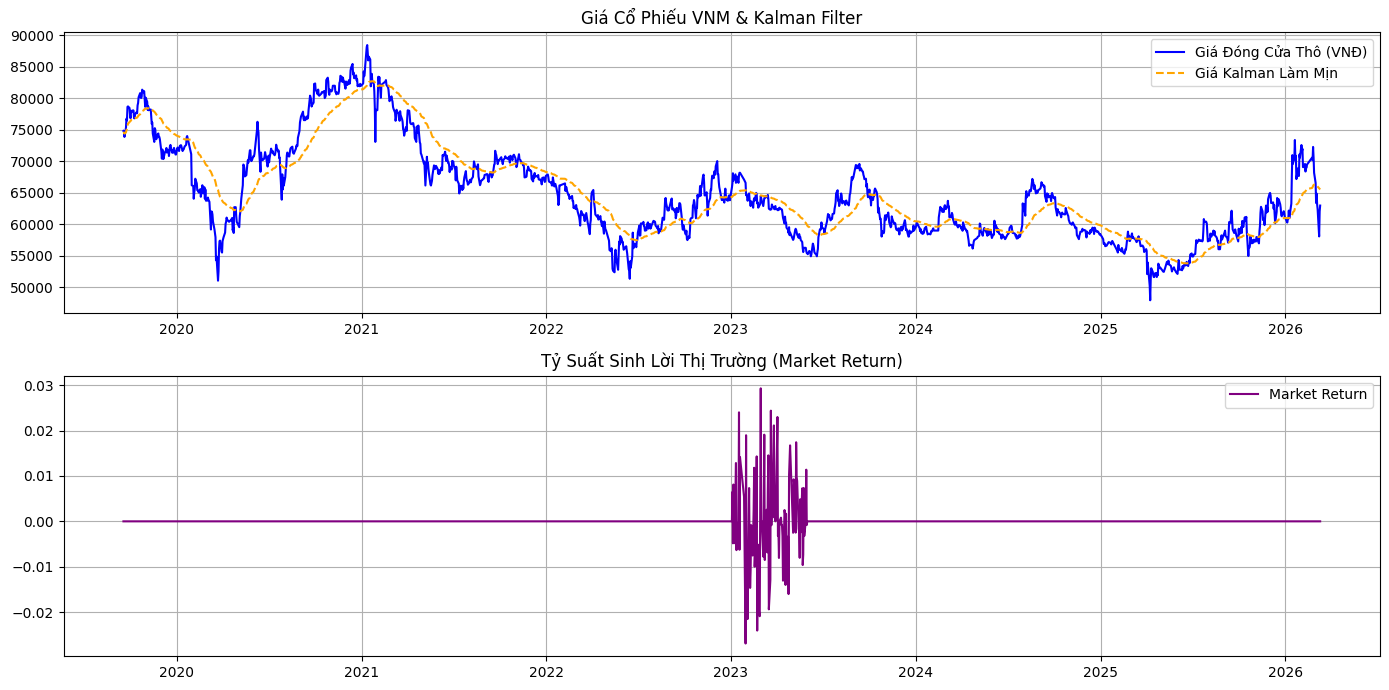

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(14, 7))

# Biểu đồ giá và Giá Kalman làm mịn
plt.subplot(2, 1, 1)
plt.plot(df_sample['date'], df_sample['close'], label='Giá Đóng Cửa Thô (VNĐ)', color='blue')
plt.plot(df_sample['date'], df_sample['close_smoothed'], label='Giá Kalman Làm Mịn', color='orange', linestyle='--')
plt.title('Giá Cổ Phiếu VNM & Kalman Filter')
plt.legend()
plt.grid(True)

# Biểu đồ Market Return
plt.subplot(2, 1, 2)
plt.plot(df_sample['date'], df_sample['market_return'], label='Market Return', color='purple')
plt.title('Tỷ Suất Sinh Lời Thị Trường (Market Return)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()